In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms.functional as TF
from sklearn.metrics import precision_score, f1_score,recall_score,accuracy_score
!pip install torchsummary
from torchsummary import summary
from torch.optim.lr_scheduler import StepLR

import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import random
from torch.utils.data import Dataset,random_split,DataLoader,Subset

!pip install timm
import timm

!pip install torchview
import torchvision
from torchview import draw_graph

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
!mkdir output

In [3]:
class SlumDataset(Dataset):
  def __init__(self,image_dir,mask_dir,transform = None):
    self.image_dir = image_dir
    self.mask_dir = mask_dir
    self.transform = transform
    self.images = os.listdir(image_dir)
    self.masks = os.listdir(mask_dir)

  def __len__(self):
    return len(self.masks)

  def __getitem__(self,index):
    img_path = os.path.join(self.image_dir,self.images[index])
    mask_path = os.path.join(self.mask_dir,self.masks[index])

    image = np.array(Image.open(img_path))
    mask = np.array(Image.open(mask_path), dtype = np.float32)
    mask = (mask//246.0)
    image = (image/255.0)


    if self.transform != None:
      augment = self.transform(image = image,mask = mask)
      image = augment['image']
      mask = augment['mask']

      if(image.shape[1:] != mask.shape):
        print("-------------- ---------------------------")
        print("!!!Warning!!!")
        print(image.shape[1:])
        print(mask.shape)

    return image,mask

In [4]:
def save_checkpoint(state,filename = "my_checkpoint.pth.tar"):
  print("=> Saving checkpoint")
  torch.save(state,filename)

def load_checkpoint(checkpoint,model,optimizer):
  print("=> Loading checkpoint")
  model.load_state_dict(checkpoint["state_dict"])
  optimizer.load_state_dict(checkpoint["optimizer"])

In [5]:
def get_loaders(
    train_dir,
    train_mask_dir,
    val_dir,
    val_mask_dir,
    batch_size,
    train_transform,
    val_transform,
    train_val,
    num_workers = 2,
    pin_memory = True,
):

  train_ds = SlumDataset(
      image_dir = train_dir,
      mask_dir = train_mask_dir,
      transform = train_transform
  )

  train_loader = DataLoader(
      train_ds,
      batch_size = batch_size,
      num_workers = num_workers,
      pin_memory = pin_memory,
      shuffle = True,
  )

  val_ds = SlumDataset(
      image_dir = val_dir,
      mask_dir = val_mask_dir,
      transform = val_transform
  )

  val_loader = DataLoader(
      val_ds,
      batch_size = batch_size,
      num_workers = num_workers,
      pin_memory = pin_memory,
      shuffle = False,
  )

  return train_loader, val_loader

In [6]:
def dice_coefficient(predicted_mask, ground_truth_mask):
  intersection = np.sum(predicted_mask * ground_truth_mask)
  predicted_area = np.sum(predicted_mask)
  ground_truth_area = np.sum(ground_truth_mask)

  dice = (2.0 * intersection) / (predicted_area + ground_truth_area)
  return dice

def check_accuracy(loss_fn,loader,model,accuracy_vals,dice_scores,iou_scores,precision_scores,recall_scores,f1_val,val_loss,device = "cuda"):
  num_correct = 0
  num_pixels = 0
  dice_s = []
  precision_s = []
  f1_s = []
  iou_s = []
  recall_s = []
  accuracy_s = []
  model.eval()

  with torch.no_grad():
    for x,y in loader:
      x = x.to(device)
      y = y.to(device).unsqueeze(1)
      pred = torch.sigmoid(model(x))

      val_loss += loss_fn(y,pred).item()

      pred = (pred > 0.5).float()
      num_correct += (pred == y).sum()
      num_pixels += torch.numel(pred)
      preds = pred.cpu().numpy()
      yy = y.cpu().numpy()


      for pred_mask, gt_mask in zip(preds, yy):
        # Flatten the binary masks for precision calculation
        pred_mask_flat = pred_mask.flatten()
        gt_mask_flat = gt_mask.flatten()

        # Calculate recall score for the current mask
        recall = recall_score(gt_mask_flat, pred_mask_flat)
        recall_s.append(recall)

        # Calculate precision for the current mask
        precision = precision_score(gt_mask_flat, pred_mask_flat)
        precision_s.append(precision)

        # Calculate F1 score for the current mask
        # F1-score is the harmonic mean of Precision and Recall,
        # F1-score = 2 * (Precision * Recall) / (Precision + Recall)

        f1 = f1_score(gt_mask_flat, pred_mask_flat)
        f1_s.append(f1)

        # Calculate the intersection and union of the binary masks
        intersection = np.sum(pred_mask * gt_mask)
        union = np.sum(np.logical_or(pred_mask, gt_mask))

        # Calculate IoU for the current mask
        iou = intersection / union
        iou_s.append(iou)

        # Calculate Accuarcy for the current mask
        accuracy = np.mean(gt_mask_flat == pred_mask_flat)
        accuracy_s.append(accuracy)

        dice_score = dice_coefficient(pred_mask, gt_mask)
        dice_s.append(dice_score)

  val_loss /= len(loader)
  accu = (num_correct/num_pixels)*100
  print(f"Got {num_correct}/{num_pixels} with accuracy {accu}")

  # Calculate the average precision over the validation dataset
  average_precision = np.mean(precision_s)
  print(f"Average Precision: {average_precision:.4f}")

  #Calculate the average accuracy over the validation dataset
  accuracy_vals.append(np.mean(accuracy_s))
  print(f'Accuracy: {np.mean(accuracy_s)}')

  # Calculate the average Dice score over the validation dataset
  average_dice = np.mean(dice_s)
  print(f"Average Dice Score: {average_dice:.4f}")

  # Calculate the average F1 score over the validation dataset
  average_f1 = np.mean(f1_s)
  print(f"Average F1 Score: {average_f1:.4f}")

  # Calculate the average IoU score over the validation dataset
  average_iou = np.mean(iou_s)
  print(f"Average IoU Score: {average_iou:.4f}")

  # Calculate average metrics for the epoch
  iou_scores.append(average_iou)
  precision_scores.append(average_precision)
  recall_scores.append(np.mean(recall_s))
  f1_val.append(average_f1)
  dice_scores.append(average_dice)

  model.train()

In [7]:
def save_predictions_as_imgs(loader,model,folder="saved_images/",device = "cuda"):
  model.eval()
  for idx, (x,y) in enumerate(loader):
    x = x.to(device = device)
    y = y.unsqueeze(1).to(device)

    with torch.no_grad():
      preds = torch.sigmoid(model(x))
      preds = (preds > 0.5).float()

    torchvision.utils.save_image(preds,f"{folder}/pred_{idx}.jpg")
    torchvision.utils.save_image(y,f"{folder}/{idx}.jpg")

  model.train()

In [8]:
class ConvBlock(nn.Module):
  def __init__(self,in_channels,out_channels,padding=1,kernel_size = 3,stride = 1,with_nonlinearity=True):
    super().__init__()
    self.conv = nn.Conv2d(in_channels, out_channels, padding=padding, kernel_size=kernel_size, stride=stride)
    self.bn = nn.BatchNorm2d(out_channels)
    self.relu = nn.ReLU()
    self.with_nonlinearity = with_nonlinearity

  def forward(self,x):
    x = self.conv(x)
    x = self.bn(x)
    if self.with_nonlinearity:
        x = self.relu(x)

    return x

In [9]:
class Bridge(nn.Module):
  def __init__(self, in_channels, out_channels):
    super().__init__()
    self.bridge = nn.Sequential(
        ConvBlock(in_channels, out_channels),
        ConvBlock(out_channels, out_channels)
    )

  def forward(self, x):
    x = self.bridge(x)
    return x

In [10]:
class UpBlockForUNetWithResNet50(nn.Module):
  """
    Up block that encapsulates one up-sampling step which consists of Upsample -> ConvBlock -> ConvBlock
  """

  def __init__(self, in_channels, out_channels, up_conv_in_channels=None, up_conv_out_channels=None,upsampling_method="conv_transpose"):
    super().__init__()
    if up_conv_in_channels == None:
        up_conv_in_channels = in_channels

    if up_conv_out_channels == None:
        up_conv_out_channels = out_channels

    if upsampling_method == "conv_transpose":
        self.upsample = nn.ConvTranspose2d(up_conv_in_channels, up_conv_out_channels, kernel_size=2, stride=2)

    self.conv_block_1 = ConvBlock(in_channels, out_channels)
    self.conv_block_2 = ConvBlock(out_channels, out_channels)

  def forward(self, up_x, down_x):
    """
      :param up_x: this is the output from the previous up block
      :param down_x: this is the output from the down block
      :return: upsampled feature map
    """

    x = self.upsample(up_x)

    if x.shape != down_x.shape:
      x = TF.resize(x,size = down_x.shape[2:],antialias=False)

    x = torch.cat([x, down_x], 1)
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    return x

In [11]:
class UNetWithResnet50Encoder(nn.Module):
  DEPTH = 6

  def __init__(self, n_classes=1):
    super().__init__()
    resnet = torchvision.models.resnet.resnet50(pretrained=True)
    for param in resnet.parameters():
      param.requires_grad = False

    down_blocks = []
    up_blocks = []

    self.input_block = nn.Sequential(*list(resnet.children()))[:3]
    self.input_pool = list(resnet.children())[3]

    for bottleneck in list(resnet.children()):
        if isinstance(bottleneck, nn.Sequential):
            down_blocks.append(bottleneck)

    self.down_blocks = nn.ModuleList(down_blocks)
    self.bridge = Bridge(2048, 2048)

    up_blocks.append(UpBlockForUNetWithResNet50(2048, 1024))
    up_blocks.append(UpBlockForUNetWithResNet50(1024, 512))
    up_blocks.append(UpBlockForUNetWithResNet50(512, 256))
    up_blocks.append(UpBlockForUNetWithResNet50(in_channels=128 + 64, out_channels=128,up_conv_in_channels=256, up_conv_out_channels=128))
    up_blocks.append(UpBlockForUNetWithResNet50(in_channels=64 + 3, out_channels=64,up_conv_in_channels=128, up_conv_out_channels=64))

    self.up_blocks = nn.ModuleList(up_blocks)
    self.out = nn.Conv2d(64, n_classes, kernel_size=1, stride=1)

  def forward(self, x, with_output_feature_map=False):
    pre_pools = dict()
    pre_pools[f"layer_0"] = x

    x = self.input_block(x)
    pre_pools[f"layer_1"] = x

    x = self.input_pool(x)

    for i, block in enumerate(self.down_blocks, 2):
        x = block(x)
        if i == (UNetWithResnet50Encoder.DEPTH - 1):
            continue
        pre_pools[f"layer_{i}"] = x

    x = self.bridge(x)

    for i, block in enumerate(self.up_blocks, 1):
        key = f"layer_{UNetWithResnet50Encoder.DEPTH - 1 - i}"
        x = block(x, pre_pools[key])

    output_feature_map = x

    x = self.out(x)
    del pre_pools

    if with_output_feature_map:
        return x, output_feature_map
    else:
        return x

In [12]:
model = UNetWithResnet50Encoder()

/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 246MB/s]


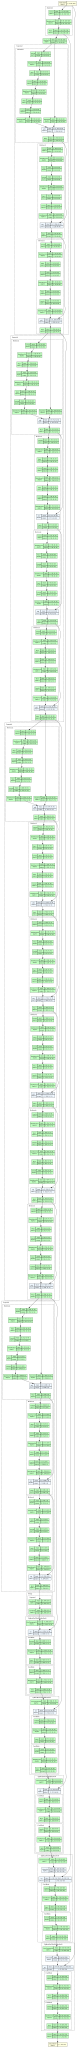

In [13]:
model_graph = draw_graph(model, input_size=(1,3,256,256), expand_nested=True)
model_graph.visual_graph

In [14]:
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
from numpy import random

import numpy as np
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt

# Hyperparameters
LEARNING_RATE = 1e-4
device = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
NUM_EPOCHS = 15
NUM_WORKERS = 2
train_val = 0.8
IMAGE_HEIGHT = 256
IMAGE_WIDTH = 256
train_valid = 0.8

PIN_MEMORY = True
LOAD_MODEL = True

TRAIN_IMG_DIR = '/kaggle/input/slum-area-dataset/Data/train_img'
TRAIN_MASK_DIR = '/kaggle/input/slum-area-dataset/Data/train_mask'
val_dir = '/kaggle/input/slum-area-dataset/Data/val_img/val_img'
val_mask_dir = '/kaggle/input/slum-area-dataset/Data/val_mask/val_mask'
saved_folder = '/kaggle/working/output'

In [15]:
# Custom Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        BCE_loss = nn.BCEWithLogitsLoss()(inputs, targets)
        pt = torch.exp(-BCE_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss
        return focal_loss

In [16]:
def train_fn(epoch,num_epochs,loader,model,optimizer,loss_fn,scaler,iou_train,precision_train,recall_train,f1_train,loss_train,accuracy_train):
  total_loss = 0.0
  total_iou = 0.0
  total_precision = 0.0
  total_recall = 0.0
  total_f1 = 0.0
  total_accuracy = 0.0
  accuracy_s = []

  length = len(loader);
  loop = tqdm(loader)

  for batch_idx, (data,targets) in enumerate(loop):
    data = data.to(device = device)
    targets = targets.float().unsqueeze(1).to(device = device)
    targ = targets

    # forward
    with torch.cuda.amp.autocast():
      predictions = torch.sigmoid(model(data))

      loss = loss_fn(predictions,targets)
      total_loss += loss.item()

      # convert model outputs to binary mask using sigmoid and threshold
      predicted_masks = predictions
      predicted_masks = (predicted_masks > 0.5).float()

      preds = predicted_masks.cpu().numpy()
      yy = targ.cpu().numpy()

      # Calculate the intersection and union of the binary masks
      intersection = np.sum(preds * yy)
      union = np.sum(np.logical_or(preds, yy))
      iou = intersection / union

      precision = precision_score(yy.flatten(), preds.flatten())
      recall = recall_score(yy.flatten(), preds.flatten())
      f1 = f1_score(yy.flatten(), preds.flatten())
    
      for pred_mask,gt_mask in zip(preds,yy):
        x = np.mean(gt_mask.flatten() == pred_mask.flatten())
        accuracy_s.append(x)

      total_iou += iou
      total_precision += precision
      total_recall += recall
      total_f1 += f1
      # total_accuracy += accuracy

    # backward
    optimizer.zero_grad()
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    # update tqdm loop
    loop.set_postfix(loss = loss.item())

  average_loss = total_loss / length
  average_iou = total_iou / length
  average_precision = total_precision / length
  average_recall = total_recall / length
  average_f1 = total_f1 / length
  # average_accuracy = accuracy /length

  # Append metrics and losses to lists for plotting
  loss_train.append(average_loss)
  iou_train.append(average_iou)
  precision_train.append(average_precision)
  recall_train.append(average_recall)
  f1_train.append(average_f1)
  accuracy_train.append(np.mean(accuracy_s))

  print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Loss: {average_loss:.4f}, "
          f"IoU: {average_iou:.4f}, "
          f"Precision: {average_precision:.4f}, "
          f"Recall: {average_recall:.4f}, "
          f"F1: {average_f1:.4f},"
          f"Accuracy: {np.mean(accuracy_s):4f}"
  )


/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/opt/conda/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:139: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See m

Epoch [1/15], Loss: 0.1821, IoU: 0.5677, Precision: 0.7778, Recall: 0.6866, F1: 0.7207,Accuracy: 0.848732
=> Saving checkpoint
Got 41823709/46530560 with accuracy 89.88438415527344
Average Precision: 0.6335
Accuracy: 0.8988438780878631
Average Dice Score: 0.7394
Average F1 Score: 0.7394
Average IoU Score: 0.6024


100%|██████████| 178/178 [08:20<00:00,  2.81s/it, loss=0.14]


Epoch [2/15], Loss: 0.1659, IoU: 0.5780, Precision: 0.8328, Recall: 0.6598, F1: 0.7307,Accuracy: 0.863129
=> Saving checkpoint


/opt/conda/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


...

Epoch [13/15], Loss: 0.1527, IoU: 0.6102, Precision: 0.8569, Recall: 0.6837, F1: 0.7562,Accuracy: 0.875512
=> Saving checkpoint
Got 43237902/46530560 with accuracy 92.92366790771484
Average Precision: 0.7537
Accuracy: 0.9292366565113336
Average Dice Score: 0.7935
Average F1 Score: 0.7935
Average IoU Score: 0.6735


100%|██████████| 178/178 [07:58<00:00,  2.69s/it, loss=0.157]


Epoch [14/15], Loss: 0.1530, IoU: 0.6059, Precision: 0.8548, Recall: 0.6801, F1: 0.7528,Accuracy: 0.874182
=> Saving checkpoint
Got 43386124/46530560 with accuracy 93.2422103881836
Average Precision: 0.7699
Accuracy: 0.9324221328950264
Average Dice Score: 0.7962
Average F1 Score: 0.7962
Average IoU Score: 0.6774


100%|██████████| 178/178 [07:53<00:00,  2.66s/it, loss=0.147]


Epoch [15/15], Loss: 0.1526, IoU: 0.6091, Precision: 0.8575, Recall: 0.6821, F1: 0.7555,Accuracy: 0.875480
=> Saving checkpoint
Got 43346910/46530560 with accuracy 93.15794372558594
Average Precision: 0.7684
Accuracy: 0.931579374931228
Average Dice Score: 0.7942
Average F1 Score: 0.7942
Average IoU Score: 0.6750
Training finished
loss_train : [0.18210630043503945, 0.16587856219390804, 0.1589137525036094, 0.15530336941226144, 0.15441820092415542, 0.15387931733988644, 0.15330640954917737, 0.15298178591085285, 0.1527546224801728, 0.152674796457371, 0.15243683345197293, 0.15231394675675403, 0.15270780792899347, 0.15297679435671047, 0.15264741737353668]
iou_train : [0.5677270648465579, 0.5779764620641898, 0.5819938222482047, 0.5965998707469466, 0.6030706296672282, 0.6036298101768143, 0.606271823079032, 0.6047556257438604, 0.606891028458425, 0.6110437023085805, 0.6140668195137313, 0.6133322236835581, 0.610196757136771, 0.6059102899986342, 0.60912188871678]
precision_train : [0.77780533892213

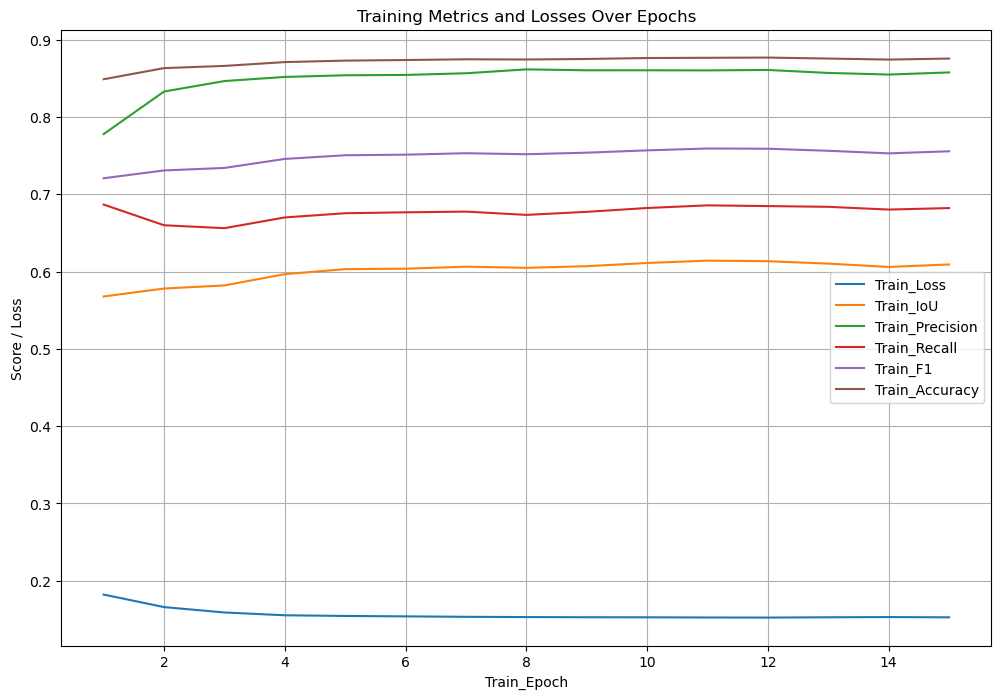

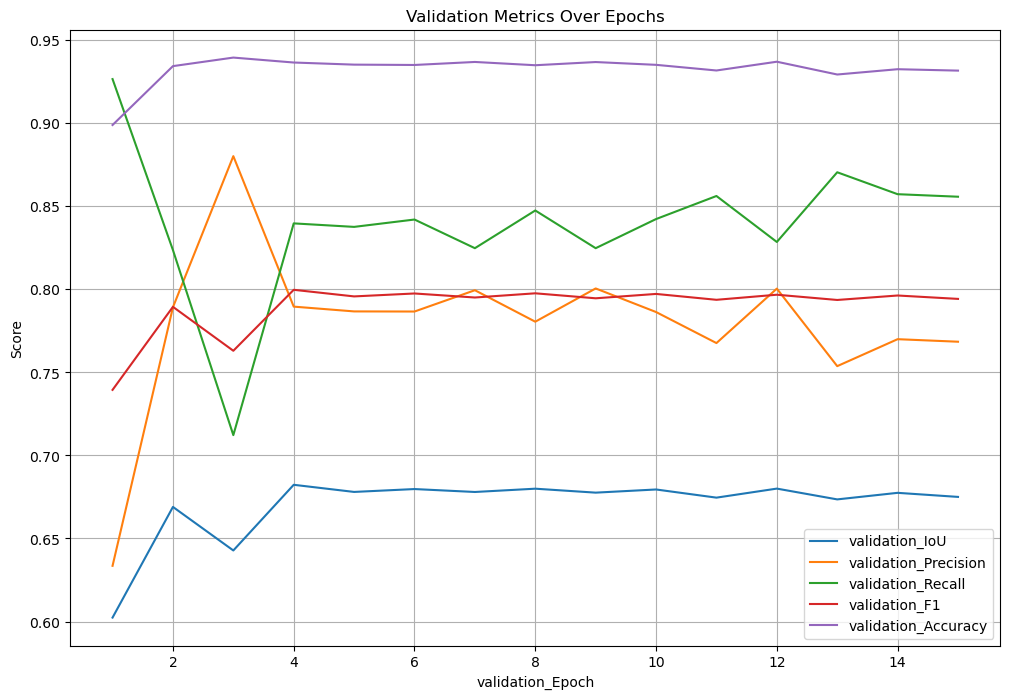

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 128, 128]           9,408
       BatchNorm2d-2         [-1, 64, 128, 128]             128
              ReLU-3         [-1, 64, 128, 128]               0
         MaxPool2d-4           [-1, 64, 64, 64]               0
            Conv2d-5           [-1, 64, 64, 64]           4,096
       BatchNorm2d-6           [-1, 64, 64, 64]             128
              ReLU-7           [-1, 64, 64, 64]               0
            Conv2d-8           [-1, 64, 64, 64]          36,864
       BatchNorm2d-9           [-1, 64, 64, 64]             128
             ReLU-10           [-1, 64, 64, 64]               0
           Conv2d-11          [-1, 256, 64, 64]          16,384
      BatchNorm2d-12          [-1, 256, 64, 64]             512
           Conv2d-13          [-1, 256, 64, 64]          16,384
      BatchNorm2d-14          [-1, 256,

In [17]:
def main():
  train_transform = A.Compose(
    [
      A.Resize(height = IMAGE_HEIGHT,width = IMAGE_WIDTH),
      A.RandomCrop(height = IMAGE_HEIGHT,width=IMAGE_WIDTH),
      A.Rotate(limit = 35,p=1.0),
      A.HorizontalFlip(p=0.5),
      A.VerticalFlip(p=0.1),
      A.Normalize(
          mean=[0.0,0.0,0.0],
          std = [1.0,1.0,1.0],
          max_pixel_value = 1.0
      ),
      ToTensorV2(),
    ], is_check_shapes=False
  )

  val_transform = A.Compose(
    [
     A.Resize(height = IMAGE_HEIGHT,width = IMAGE_WIDTH),
     A.RandomCrop(height = IMAGE_HEIGHT,width=IMAGE_WIDTH),
     A.Normalize(
      mean=[0.0,0.0,0.0],
      std = [1.0,1.0,1.0],
      max_pixel_value = 1.0
    ),
    ToTensorV2(),
  ], is_check_shapes=False
  )

  train_loader,val_loader = get_loaders(
      TRAIN_IMG_DIR,
      TRAIN_MASK_DIR,
      val_dir,
      val_mask_dir,
      BATCH_SIZE,
      train_transform,
      val_transform,
      train_val,
      NUM_WORKERS,
      PIN_MEMORY,
  )

  model = UNetWithResnet50Encoder().to("cuda" if torch.cuda.is_available() else "cpu")
  loss_fn = FocalLoss()

  optimizer = optim.Adam(model.parameters(),lr = LEARNING_RATE)
  scheduler = StepLR(optimizer, step_size=4, gamma=0.1)

  # if LOAD_MODEL:
    # load_checkpoint(torch.load("my_checkpoint.pth.tar"),model)
    # load_checkpoint(torch.load("my_checkpoint.pth.tar"),model,optimizer=optimizer)

  scaler = torch.cuda.amp.GradScaler()

  # Initialize lists to store metric values for each epoch for validation dataset
  iou_scores = []
  precision_scores = []
  recall_scores = []
  f1_val = []
  dice_scores = []
  accuracy_vals = []

  # Initialize lists to store metric values for each epoch for training dataset
  iou_train = []
  precision_train = []
  recall_train = []
  f1_train = []
  loss_train = []
  accuracy_train = []

  # Number of patience for early stopping
  patience = 10
  # best_val_loss = float('inf')
  best_val_loss = torch.tensor(float('inf'))
  counter = 0

  for epoch in range(NUM_EPOCHS):
    scheduler.step()
    train_fn(epoch,NUM_EPOCHS,train_loader,model,optimizer,loss_fn,scaler,iou_train,precision_train,recall_train,f1_train,loss_train,accuracy_train)

    # save model
    checkpoint = {
        "state_dict": model.state_dict(),
        "optimizer": optimizer.state_dict(),
    }
    save_checkpoint(checkpoint)

    # check_accuracy
    val_loss = 0.0
    check_accuracy(loss_fn,val_loader,model,accuracy_vals,dice_scores,iou_scores,precision_scores,recall_scores,f1_val,val_loss,device = DEVICE)

#     if val_loss < best_val_loss:
#         best_val_loss = val_loss
#         counter = 0
#     else:
#         counter += 1
#         if counter >= patience:
#             print("Early stopping triggered.")
#             break

    # print some examples to the folder
    save_predictions_as_imgs(
        val_loader,model,folder=saved_folder,device = DEVICE
    )
  print("Training finished")
  print(f'loss_train : {loss_train}')
  print(f'iou_train : {iou_train}')
  print(f'precision_train : {precision_train}')
  print(f'recall_train : {recall_train}')
  print(f'f1_train : {f1_train}')
  
  print(f'Validation result')
  print(f'f1_val: {f1_val}')
  print(f'dice_scores : {dice_scores}')
  print(f'iou_scores : {iou_scores}')
  print(f'precision_scores : {precision_scores}')
  print(f'recall_scores : {recall_scores}')
  print(f'Accuracy_scores : {accuracy_vals}')

  # Plot metrics and losses
  # Plot for Training dataset
  epochs = np.arange(1, NUM_EPOCHS + 1)
  plt.figure(figsize=(12, 8))

  plt.plot(epochs, loss_train, label='Train_Loss')
  plt.plot(epochs, iou_train, label='Train_IoU')
  plt.plot(epochs, precision_train, label='Train_Precision')
  plt.plot(epochs, recall_train, label='Train_Recall')
  plt.plot(epochs, f1_train, label='Train_F1')
  plt.plot(epochs, accuracy_train, label='Train_Accuracy')

  plt.xlabel('Train_Epoch')
  plt.ylabel('Score / Loss')
  plt.title('Training Metrics and Losses Over Epochs')
  plt.legend()
  plt.grid()

  plt.show()

  # PLot validation metrics
  plt.figure(figsize=(12, 8))

  plt.plot(epochs, iou_scores, label='validation_IoU')
  plt.plot(epochs, precision_scores, label='validation_Precision')
  plt.plot(epochs, recall_scores, label='validation_Recall')
  plt.plot(epochs, dice_scores, label='validation_F1')
  plt.plot(epochs,accuracy_vals,label = "validation_Accuracy")

  plt.xlabel('validation_Epoch')
  plt.ylabel('Score')
  plt.title('Validation Metrics Over Epochs')
  plt.legend()
  plt.grid()

  plt.show()

  summary(model,input_size = (3,IMAGE_HEIGHT,IMAGE_WIDTH))

if __name__ == "__main__":
  main()